# Landweber iteration and discrepancy principle
In this lab, you should solve a three-dimensional tomography problem with the Landweber method. Have a look at the lecture slides to see how this method works. Here are some general hints:

* Start by choosing an appropriate discretized space with three dimensions and symmetric min/max points around zero, starting with $32 \times 32 \times 32$ resolution for testing, and initialize it with odl. *If you do not have access to a suitable GPU, or if you have not installed the optional dependency with astra-toolbox, then this lab must be done in two dimensions.*

* Create a three-dimensional [Shepp–Logan phantom](https://odlgroup.github.io/odl/generated/odl.phantom.transmission.shepp_logan.html) in the space. Use ``show`` to make sure that the image are centered at the origin. 

* Form the [ray transform operator](http://odlgroup.github.io/odl/generated/odl.tomo.operators.ray_trafo.RayTransform.html) using a [cone beam geometry](http://odlgroup.github.io/odl/generated/odl.tomo.geometry.conebeam.cone_beam_geometry.html#odl.tomo.geometry.conebeam.cone_beam_geometry) with a small number $(\sim 10)$ of angles, otherwise you will not see the effects of semi-convergence. 

* Apply the operator to the phantom to obtain the sinogram, and add some noise to the sinogram (which lives in the space ``Operator.range``). 

* You get the norm of a space element with its [norm method](https://odlgroup.github.io/odl/generated/odl.discr.discr_space.DiscretizedSpaceElement.norm.html#odl.discr.discr_space.DiscretizedSpaceElement.norm). For the discrepancy in the Landweber method, you will need the noise level $\| g - g_{\mathrm{noisy}}\|$ of the sinogram $g$. (In real applications you must estimate the noise level, but let us keep this example simple.)

* Get the adjoint of the forward operator, e.g., ``Operator.adjoint``.

* You can obtain an estimate of the largest singular value of the forward operator with its [norm method](http://odlgroup.github.io/odl/generated/odl.operator.operator.Operator.norm.html). (Note that this is operator norm, which may need to be estimated if it is not directly available in odl).

* Implement Landweber and employ $\sim 200$ iterations to obtain a solution for the noisy sinogram, starting with the [zero vector](https://odlgroup.github.io/odl/generated/odl.discr.discr_space.DiscretizedSpace.zero.html#odl.discr.discr_space.DiscretizedSpace.zero) of the space.

* Log the relevant norms between iterations and check if the discrepancy criterion is satisfied (but do not stop the iteration).

* Plot the relative error of your reconstruction depending on the number of iterations, and see what the discrepancy criterion would give you.

* Compare your solution to that obtained with the [built-in version of Landweber](https://odlgroup.github.io/odl/generated/odl.solvers.iterative.iterative.landweber.html#odl.solvers.iterative.iterative.landweber).

In [26]:
import odl
import numpy as np
import matplotlib.pyplot as plt

### Setting Geometry

1. Key distances

* SAD (source–axis distance) = src_radius
Distance from the x-ray source to the rotation axis (object center).

* SDD (source–detector distance) = det_radius - src_radius
Distance from the source to the detector plane.

* ADD (axis–detector distance) = det_radius
Distance from the object center to the detector plane.

**Magnification**

$$
    M = \frac{\text{SDD}}{\text{SAD}}
$$

Affects how large the object projects onto the detector. Too large magnification → fewer object voxels fit onto the detector.

**Cone angle**:
Determined by detector size and ratio SAD/SDD. Larger cone angle increases coverage in the z-direction but also introduces cone-beam artifacts if reconstruction method isn’t adapted.

**Field of view (FOV)**:
To fully cover an object of radius R, you need

$$
    R \leq \frac{\text{SAD}}{\text{SDD}}\cdot \frac{\text{det width}}{2}
$$


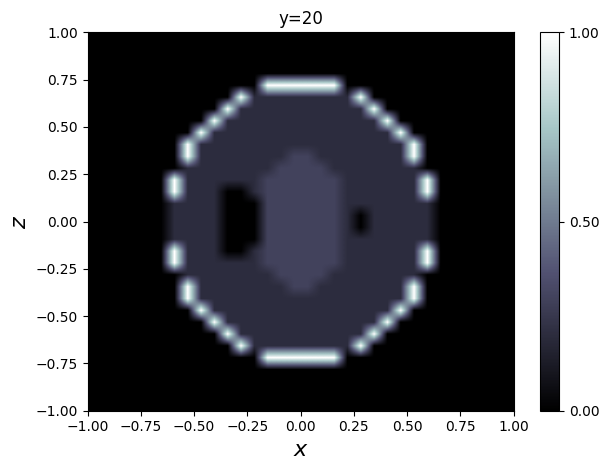

<Figure size 640x480 with 0 Axes>

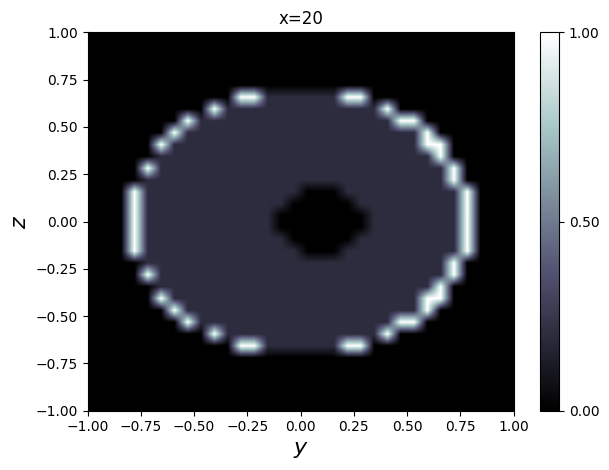

<Figure size 640x480 with 0 Axes>

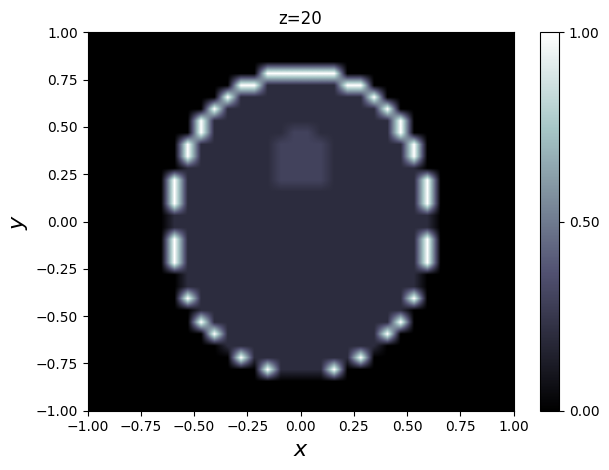

<Figure size 640x480 with 0 Axes>

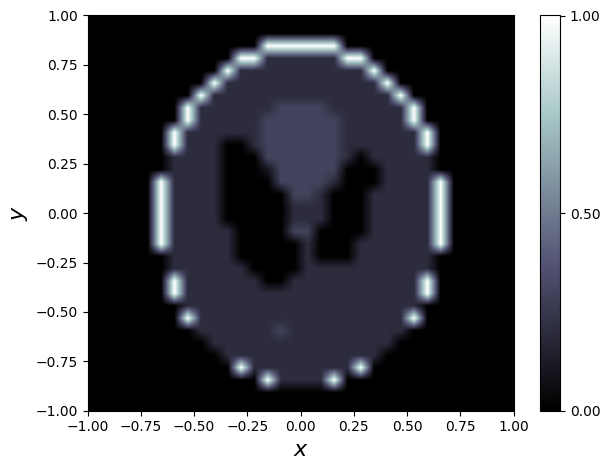

<Figure size 640x480 with 0 Axes>

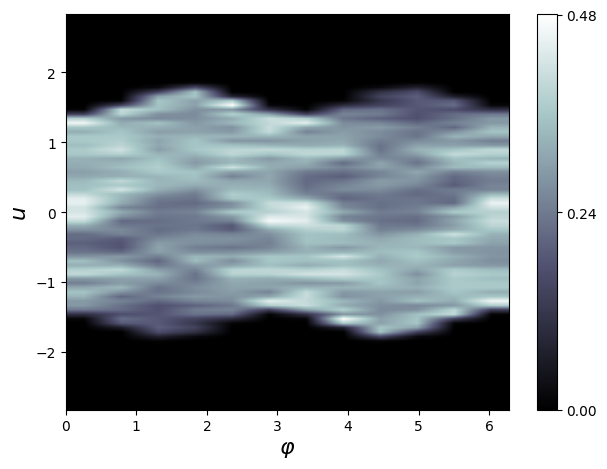

<Figure size 640x480 with 0 Axes>

In [27]:
space = odl.discr.discr_space.uniform_discr([-1, -1, -1], [1, 1, 1], (32, 32, 32))

phantom = odl.phantom.transmission.shepp_logan(space=space, modified=True)
# y-slice at index 20  (axis 1 fixed)
phantom.show(indices=(slice(None), 20, slice(None)), title="y=20")

# x-slice at index 20  (axis 0 fixed)
phantom.show(indices=(20, slice(None), slice(None)), title="x=20")

# z-slice at index 20  (axis 2 fixed)
phantom.show(indices=(slice(None), slice(None), 20), title="z=20")


geometry = odl.tomo.geometry.conebeam.cone_beam_geometry(space=space, 
                                                         src_radius=5,
                                                         det_radius=5, 
                                                         num_angles=12)
Ray = odl.tomo.operators.ray_trafo.RayTransform(vol_space=space, geometry=geometry, impl="astra_cuda")

phantom.show()

sinogram = Ray(phantom)
sinogram.show()

Ray_range = Ray.range
stddev = 0.01
noisy_sinogram = sinogram + odl.phantom.white_noise(space=Ray_range, mean=0.0, stddev=stddev, seed=42)

bp_op = Ray.adjoint



### Landweber Function

In [ ]:
def Landweber(op, x_init, y, niter, x_true=None, tol=None):
    A = op
    Adj = A.adjoint
    w = 1 / A.norm(estimate=True)**2
    
    # Objective function value (error) tracking
    obj_errors = np.zeros(niter+1)
    obj_errors[0] = 0.5 * (A(x_init) - y).norm()**2
    
    # Deviation from true solution tracking (if availible)
    if not x_true is None:
        sol_errors = np.zeros(niter+1)
        sol_errors[0] = (x_init - x_true).norm()
    
    # Also store all solutions
    solutions = [x_init]
    
    x_m = x_init
    for m in range(1, niter+1):
        x_mp1 =  x_m - w * Adj(A(x_m) - y)
        x_m = x_mp1
        
        # Store norms
        sol_errors[m] = (x_m - x_true).norm()
        obj_errors[m] = 0.5 * (A(x_m) - y).norm()**2
        solutions.append(x_m)
        if not tol is None and obj_errors[m] < tol:
            print(f"Exit Tolerance met after {m} iterations")
            obj_errors = obj_errors[:m+2]
            if x_true is not None:
                sol_errors = sol_errors[:m+2]
            break
    
    # find best solution if able
    best_sol = None
    if x_true is not None:
        best_sol = solutions[int(np.argmin(sol_errors))]
    return best_sol, solutions, (sol_errors if x_true is not None else None), obj_errors

        

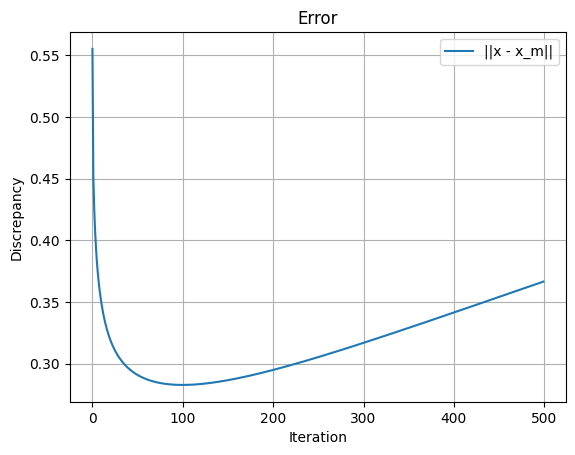

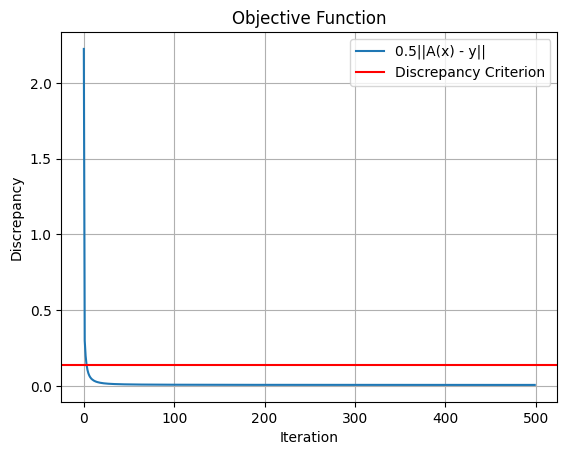

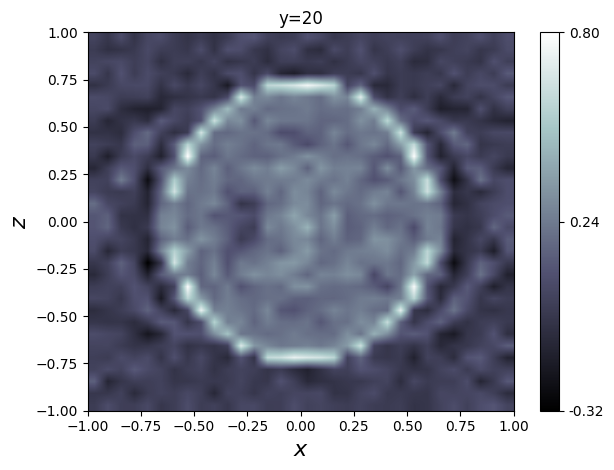

<Figure size 640x480 with 0 Axes>

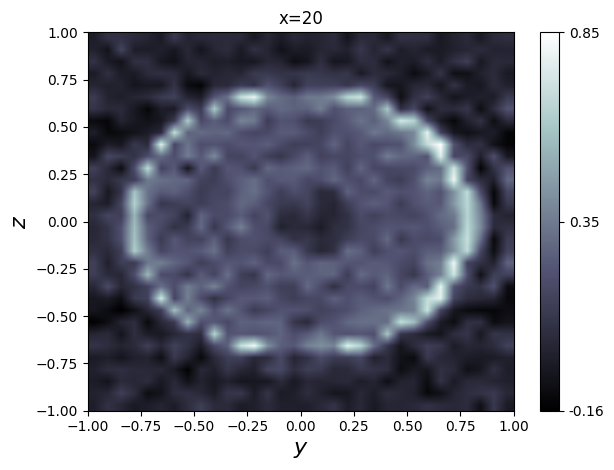

<Figure size 640x480 with 0 Axes>

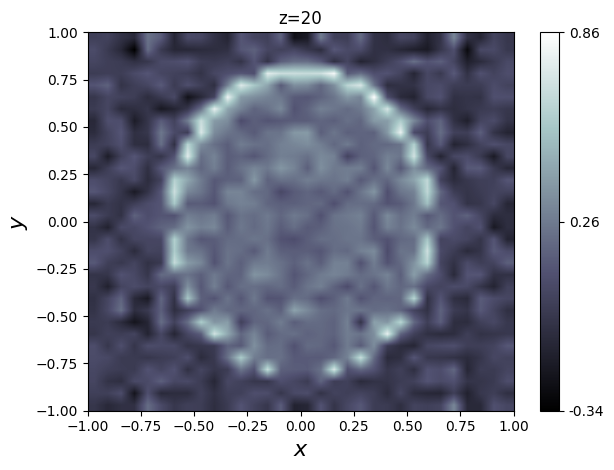

<Figure size 640x480 with 0 Axes>

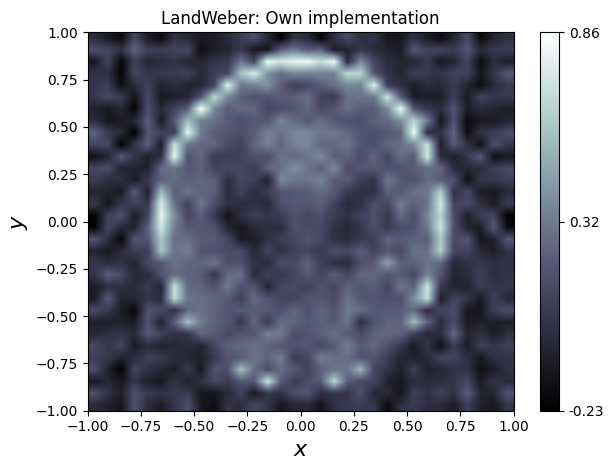

<Figure size 640x480 with 0 Axes>

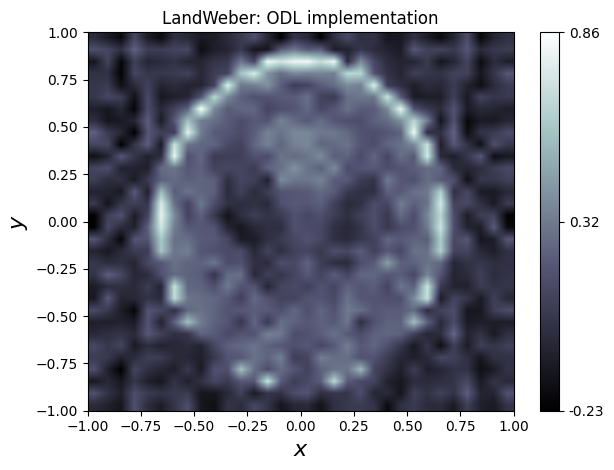

<Figure size 640x480 with 0 Axes>

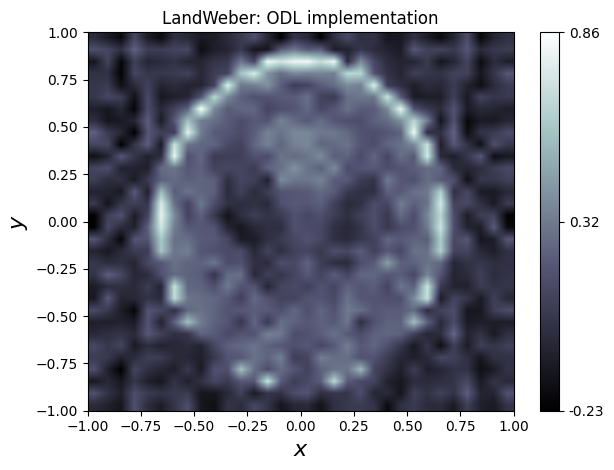

In [ ]:
x_init = space.zero()
nr_iter = 500
best_sol, solutions, sol_errors, obj_errors = Landweber(op=Ray, 
                                                        x_init=x_init, 
                                                        y=noisy_sinogram, 
                                                        niter=nr_iter, 
                                                        x_true=phantom)

plt.plot(np.arange(nr_iter), sol_errors, label="||x - x_m||")
plt.xlabel("Iteration"); plt.ylabel("Discrepancy")
plt.title("Error")
plt.legend(); plt.grid(True)
plt.show()

plt.plot(np.arange(nr_iter), obj_errors, label="0.5||A(x) - y||^2")
plt.axhline(y=(noisy_sinogram-sinogram).norm(), color="r", label="Discrepancy Criterion")
plt.xlabel("Iteration"); plt.ylabel("Discrepancy")
plt.title("Objective Function")
plt.legend(); plt.grid(True)
plt.show()

# y-slice at index 20  (axis 1 fixed)
best_sol.show(indices=(slice(None), 20, slice(None)), title="y=20")

# x-slice at index 20  (axis 0 fixed)
best_sol.show(indices=(20, slice(None), slice(None)), title="x=20")

# z-slice at index 20  (axis 2 fixed)
best_sol.show(indices=(slice(None), slice(None), 20), title="z=20")

best_sol.show(title="LandWeber: Own implementation")

x = x_init
odl.solvers.iterative.iterative.landweber(op=Ray, 
                                          x=x, 
                                          rhs=noisy_sinogram, 
                                          niter=np.argmin(sol_errors))
x.show(title="LandWeber: ODL implementation")

